<a href="https://colab.research.google.com/github/muhammadhasbiashiddiqi/Kuis_PM_1/blob/main/kuis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
from google.colab import drive
import pandas as pd
import numpy as np
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
file_path = "/content/drive/MyDrive/PM/Dataset TI-3B.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

In [45]:
print("data awal:")
print(df.head())
print("\nKolom yang ada:")
print(df.columns.tolist())

data awal:
   no                  nama lengkap jenis kelamin    kota asal  \
0   1  Alfreda Dhaifullah Mahezwara             L       malang   
1   2        Angga Saputra Ramadhan             L  probolinggo   
2   3  Ardhan Dikri Achmad Fahrudin             L       malang   
3   4  Arjuna Carly Dhymas Mahendra             L     sidoarjo   
4   5                 Arya Ramadhan             L       malang   

   tinggi badan (cm) asal kelas  target IP smt 5 warna kesukaan        hobi  \
0                172         2C                4     Red Marron     Main ML   
1                163         2B                4          Putih  Sepak Bola   
2                172         2H                4           Biru      Basket   
3                165         2B                4           Biru      Basket   
4                175         2G                4           Ungu    Berenang   

               film fav genre musik        idola     kota fav     makanan fav  \
0       The Shadow Edge     Britpop 

In [46]:
df.columns = df.columns.str.strip()
print("\nnormalisasi:")
print(df.columns.tolist())


normalisasi:
['no', 'nama lengkap', 'jenis kelamin', 'kota asal', 'tinggi badan (cm)', 'asal kelas', 'target IP smt 5', 'warna kesukaan', 'hobi', 'film fav', 'genre musik', 'idola', 'kota fav', 'makanan fav', 'minuman fav', 'negara yang ingin dikunjungi']


In [47]:
if 'kota asal' in df.columns:
    df['kota asal'] = df['kota asal'].str.lower().str.strip()
    df['kota asal'] = df['kota asal'].str.replace('kota ', '', regex=False)
    df['kota asal'] = df['kota asal'].str.replace('kabupaten ', '', regex=False)

    print("\nsetelah dibersihkan:")
    print(df['kota asal'].unique())


setelah dibersihkan:
['malang' 'probolinggo' 'sidoarjo' 'nganjuk' 'blitar' 'bali' 'banyuwangi'
 'pasuruan' 'tulungagung' 'jakarta' 'bojonegoro' 'denpasar' 'bondowoso']


In [36]:
kota_saya = "pasuruan"
tinggi_saya = 165

In [37]:
kolom_tinggi = None
for col in df.columns:
    if 'tinggi' in col.lower() and 'badan' in col.lower():
        kolom_tinggi = col
        break

if kolom_tinggi is None:
    print("Kolom :", df.columns.tolist())
else:
    print(f"Kolom tinggi : '{kolom_tinggi}'")

✓ Kolom tinggi badan ditemukan: 'tinggi badan (cm)'


In [51]:
data_kota_saya = df[df['kota asal'].str.contains(kota_saya, case=False, na=False)]

print(f"\nmahasiswa dari kota {kota_saya.upper()}:")
print(f"Jumlah : {len(data_kota_saya)}")
print(data_kota_saya[['nama lengkap', 'kota asal', kolom_tinggi]].head(10))


mahasiswa dari kota PASURUAN:
Jumlah : 1
                nama lengkap kota asal  tinggi badan (cm)
15  Muhammad Hasbi Ashiddiqi  pasuruan                165


In [39]:
if len(data_kota_saya) > 0:
    rata_rata_tinggi = data_kota_saya[kolom_tinggi].mean()

In [52]:
print(f"Kota asal: {kota_saya.upper()}")
print(f"Rata-rata tinggi badan: {rata_rata_tinggi:.2f} cm")
print(f"Tinggi badan : {tinggi_saya} cm")

selisih = tinggi_saya - rata_rata_tinggi

if tinggi_saya > rata_rata_tinggi:
    print(f"saya lebih tinggi {abs(selisih):.2f} cm")
elif tinggi_saya < rata_rata_tinggi:
    print(f"saya lebih pendek {abs(selisih):.2f} cm")
else:
    print(f"tinggi saya sama dengan rata - rata")

Kota asal: PASURUAN
Rata-rata tinggi badan: 165.00 cm
Tinggi badan : 165 cm
tinggi saya sama dengan rata - rata


In [77]:
print(df['target IP smt 5'].unique())
print(df['target IP smt 5'].dtype)

[4]
int64


In [78]:
import re

def bersihkan_ip(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().strip()
    s = s.replace(',', '.')
    s = re.sub(r'[^0-9.]', '', s)
    s = re.sub(r'\.+', '.', s)
    try:
        return float(s)
    except ValueError:
        return np.nan

In [86]:
df['ip_bersih'] = df['target IP smt 5'].apply(bersihkan_ip)
print(df[['target IP smt 5', 'ip_bersih']].head(10))
print("\nJumlah gagal:", df['ip_bersih'].isna().sum())

   target IP smt 5  ip_bersih
0                4        4.0
1                4        4.0
2                4        4.0
3                4        4.0
4                4        4.0
5                4        4.0
6                4        4.0
7                4        4.0
8                4        4.0
9                4        4.0

Jumlah gagal: 0


In [62]:
min_ip = df['ip_bersih'].min()
max_ip = df['ip_bersih'].max()
df['ip_norm'] = (df['ip_bersih'] - min_ip) / (max_ip - min_ip)
print(f"min IP : {min_ip}")
print(f"max IP: {max_ip}")
print(df[['nama lengkap', 'ip_bersih', 'ip_norm']].head())

  - Tipe data: int64 (seharusnya numeric)
  - Nilai non-null: 25
  - Nilai null/missing: 0


In [81]:
nama_saya = "Muhammad Hasbi Ashiddiqi"
saya = df[df['nama lengkap'].str.contains(nama_saya, case=False, na=False)]
print(saya)

    no              nama lengkap jenis kelamin kota asal  tinggi badan (cm)  \
15  16  Muhammad Hasbi Ashiddiqi             L  pasuruan                165   

   asal kelas  target IP smt 5 warna kesukaan        hobi  \
15         2G                4          putih  sepak bola   

                        film fav genre musik           idola kota fav  \
15  Spiderman no way home (2021)         pop  Warren Buffett   malang   

   makanan fav minuman fav negara yang ingin dikunjungi  ip_bersih  
15      daging         jus                   findlandia        4.0  


In [83]:
df['ip_bersih'] = df['target IP smt 5'].apply(bersihkan_ip)

In [88]:
min_ip = df['ip_bersih'].min()
max_ip = df['ip_bersih'].max()
df['ip_norm'] = (df['ip_bersih'] - min_ip) / (max_ip - min_ip)
print(f"min IP : {min_ip}")
print(f"max IP: {max_ip}")
print(df[['nama lengkap', 'ip_bersih', 'ip_norm']].head())

min IP : 4.0
max IP: 4.0
                   nama lengkap  ip_bersih  ip_norm
0  Alfreda Dhaifullah Mahezwara        4.0      NaN
1        Angga Saputra Ramadhan        4.0      NaN
2  Ardhan Dikri Achmad Fahrudin        4.0      NaN
3  Arjuna Carly Dhymas Mahendra        4.0      NaN
4                 Arya Ramadhan        4.0      NaN


In [87]:
ip_saya   = df.loc[saya.index[0], 'ip_bersih']
norm_saya = df.loc[saya.index[0], 'ip_norm']

print(f"Target IP : {ip_saya}")
print(f"normalisasi Min-Max : {norm_saya:.4f}")

Target IP : 4.0
normalisasi Min-Max : nan


In [89]:
df['warna_bersih'] = (df['warna kesukaan']
                      .astype(str)
                      .str.strip()
                      .str.lower())

print(df['warna_bersih'].value_counts())

warna_bersih
biru          9
putih         4
maroon        2
hitam         2
ungu          1
red marron    1
marron        1
pink          1
abu           1
kuning        1
biru tua      1
merah muda    1
Name: count, dtype: int64


In [90]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['warna_encoded'] = le.fit_transform(df['warna_bersih'])
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for warna, kode in mapping.items():
    print(f"{kode:2d} -> {warna}")

 0 -> abu
 1 -> biru
 2 -> biru tua
 3 -> hitam
 4 -> kuning
 5 -> maroon
 6 -> marron
 7 -> merah muda
 8 -> pink
 9 -> putih
10 -> red marron
11 -> ungu


In [91]:
warna_saya = "putih"
kode_saya  = mapping[warna_saya]
kode_max   = df['warna_encoded'].max()
kode_min   = df['warna_encoded'].min()
print(f"Warna : {warna_saya}")
print(f"Kode encoding : {kode_saya} (rentang {kode_min} - {kode_max})")
if kode_saya == kode_min:
    print("=> kode kecil")
elif kode_saya == kode_max:
    print("=> kode besar")
else:
    print("=> kode netral")

Warna saya : putih
Kode encoding : 9 (rentang 0 - 11)
=> Termasuk kode DI TENGAH


In [92]:
print(sorted(mapping.items(), key=lambda x: x[1]))

[('abu', np.int64(0)), ('biru', np.int64(1)), ('biru tua', np.int64(2)), ('hitam', np.int64(3)), ('kuning', np.int64(4)), ('maroon', np.int64(5)), ('marron', np.int64(6)), ('merah muda', np.int64(7)), ('pink', np.int64(8)), ('putih', np.int64(9)), ('red marron', np.int64(10)), ('ungu', np.int64(11))]


In [95]:
df['jk_bersih'] = df['jenis kelamin'].astype(str).str.strip().str.upper()
print(df['jk_bersih'].value_counts())
kolom_tinggi = 'tinggi badan (cm)'
statistik = df.groupby('jk_bersih')[kolom_tinggi].agg(['count', 'mean', 'min', 'max'])
print("\nkelompok :")
print(statistik.round(2))

jk_bersih
L    18
P     7
Name: count, dtype: int64

kelompok :
           count    mean  min  max
jk_bersih                         
L             18  171.89  160  180
P              7  157.86  150  170


In [94]:
daftar_nama = [
    "Tsabita Keizya",
    "Alfreda Dhaifullah",
    "Muhammad Hasbi Ashiddiqi",
    "Zukhrufian Abdullah",
    "Hanggoro Nursetio Margono"
]

for nama in daftar_nama:
    data_orang = df[df['nama lengkap'].str.contains(nama, case=False, na=False)]

    if len(data_orang) == 0:
        print(f"{nama}: tidak ditemukan di dataset\n")
        continue

    baris = data_orang.iloc[0]
    jk = baris['jk_bersih']
    tinggi = baris[kolom_tinggi]
    rata_kelompok = df[df['jk_bersih'] == jk][kolom_tinggi].mean()
    selisih = tinggi - rata_kelompok

    print(f"Nama          : {nama}")
    print(f"Jenis kelamin : {jk}")
    print(f"Tinggi badan  : {tinggi} cm")
    print(f"Rata-rata {jk}     : {rata_kelompok:.2f} cm")

    if selisih > 0:
        print(f"=> Lebih tinggi {selisih:.2f} cm dari rata-rata kelompok")
    elif selisih < 0:
        print(f"=> Lebih pendek {abs(selisih):.2f} cm dari rata-rata kelompok")
    else:
        print("=> Sama persis dengan rata-rata kelompok")
    print("-" * 40)

Nama          : Tsabita Keizya
Jenis kelamin : P
Tinggi badan  : 160 cm
Rata-rata P     : 157.86 cm
=> Lebih tinggi 2.14 cm dari rata-rata kelompok
----------------------------------------
Nama          : Alfreda Dhaifullah
Jenis kelamin : L
Tinggi badan  : 172 cm
Rata-rata L     : 171.89 cm
=> Lebih tinggi 0.11 cm dari rata-rata kelompok
----------------------------------------
Nama          : Muhammad Hasbi Ashiddiqi
Jenis kelamin : L
Tinggi badan  : 165 cm
Rata-rata L     : 171.89 cm
=> Lebih pendek 6.89 cm dari rata-rata kelompok
----------------------------------------
Nama          : Zukhrufian Abdullah
Jenis kelamin : L
Tinggi badan  : 174 cm
Rata-rata L     : 171.89 cm
=> Lebih tinggi 2.11 cm dari rata-rata kelompok
----------------------------------------
Nama          : Hanggoro Nursetio Margono
Jenis kelamin : L
Tinggi badan  : 160 cm
Rata-rata L     : 171.89 cm
=> Lebih pendek 11.89 cm dari rata-rata kelompok
----------------------------------------


In [96]:
df['makanan_bersih'] = df['makanan fav'].astype(str).str.strip().str.title()
df['minuman_bersih'] = df['minuman fav'].astype(str).str.strip().str.title()

print(df['makanan_bersih'].value_counts())
print()
print(df['minuman_bersih'].value_counts())

makanan_bersih
Nasi Goreng                3
Tahu Telor                 2
Sate Ayam                  2
Ayam Geprek                1
Oyi Buttermilk             1
Bakso                      1
Nasi Pecel                 1
Mie Ayam                   1
Udang                      1
Nasi Kecap                 1
Geprek Caneyo              1
Tahu Telur                 1
Daging                     1
Sop Ayam                   1
Cumi Hitam                 1
Kalasan Cak Qodir          1
Lele Goreng                1
Iga Bakar                  1
Ayam Chili Padi            1
Cheese Cake                1
Ayam Kecombrang Taburai    1
Name: count, dtype: int64

minuman_bersih
Air Mineral                8
Air Putih                  3
Capuccino                  1
Es Teler                   1
Kapiten                    1
Es Pisang Ijo              1
Matcha                     1
Hot V60                    1
Es Teh Hangat              1
Stmj                       1
Jus                        1
Bajigur        

/tmp/ipykernel_747/1377424526.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=makanan.values, y=makanan.index, ax=axes[0], palette='viridis')
/tmp/ipykernel_747/1377424526.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=minuman.values, y=minuman.index, ax=axes[1], palette='magma')


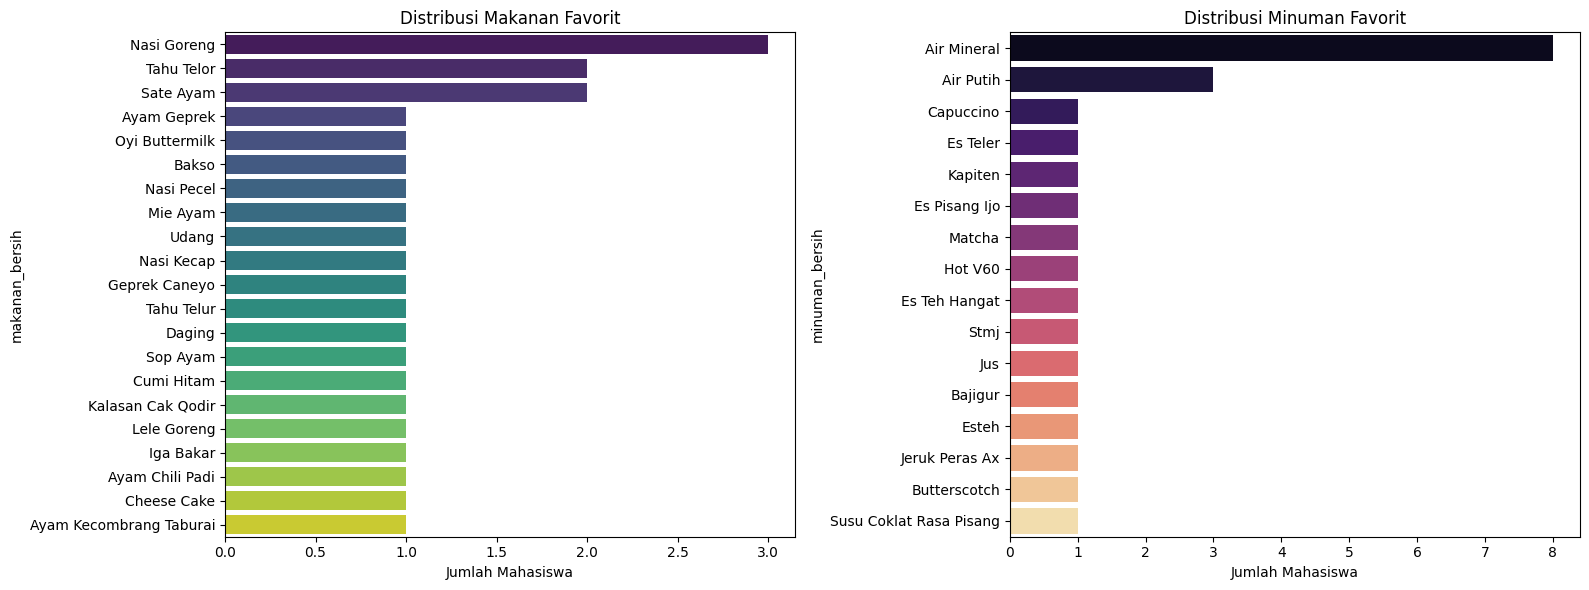

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

makanan = df['makanan_bersih'].value_counts()
minuman = df['minuman_bersih'].value_counts()

sns.barplot(x=makanan.values, y=makanan.index, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Makanan Favorit')
axes[0].set_xlabel('Jumlah Mahasiswa')

sns.barplot(x=minuman.values, y=minuman.index, ax=axes[1], palette='magma')
axes[1].set_title('Distribusi Minuman Favorit')
axes[1].set_xlabel('Jumlah Mahasiswa')

plt.tight_layout()
plt.show()

In [100]:
makanan_saya = df.loc[saya.index[0], 'makanan_bersih']
minuman_saya = df.loc[saya.index[0], 'minuman_bersih']

for label, nilai, dist in [("Makanan", makanan_saya, makanan),
                            ("Minuman", minuman_saya, minuman)]:
    jumlah = dist[nilai]
    peringkat = list(dist.index).index(nilai) + 1
    status = "DOMINAN" if jumlah > 1 else "MINORITAS (unik, hanya saya)"
    print(f"{label} favorit saya : {nilai}")
    print(f"  Dipilih {jumlah} orang, peringkat {peringkat} dari {len(dist)} pilihan -> {status}\n")

Makanan favorit saya : Daging
  Dipilih 1 orang, peringkat 13 dari 21 pilihan -> MINORITAS (unik, hanya saya)

Minuman favorit saya : Jus
  Dipilih 1 orang, peringkat 11 dari 16 pilihan -> MINORITAS (unik, hanya saya)



Q1          : 160.0
Q3          : 175.0
IQR         : 15.0
Batas bawah : 137.5
Batas atas  : 197.5

Jumlah outlier: 0


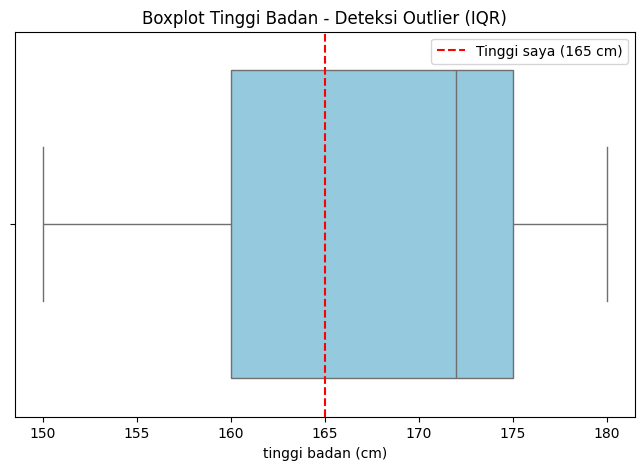

Tinggi saya (165 cm) TIDAK termasuk outlier (data normal)


In [101]:
kolom_tinggi = 'tinggi badan (cm)'

Q1  = df[kolom_tinggi].quantile(0.25)
Q3  = df[kolom_tinggi].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR

print(f"Q1          : {Q1}")
print(f"Q3          : {Q3}")
print(f"IQR         : {IQR}")
print(f"Batas bawah : {batas_bawah}")
print(f"Batas atas  : {batas_atas}")
outlier = df[(df[kolom_tinggi] < batas_bawah) | (df[kolom_tinggi] > batas_atas)]

print(f"\nJumlah outlier: {len(outlier)}")
if len(outlier) > 0:
    print(outlier[['nama lengkap', kolom_tinggi]])
plt.figure(figsize=(8, 5))
sns.boxplot(x=df[kolom_tinggi], color='skyblue')
plt.axvline(tinggi_saya, color='red', linestyle='--', label=f'Tinggi saya ({tinggi_saya} cm)')
plt.title('Boxplot Tinggi Badan - Deteksi Outlier (IQR)')
plt.legend()
plt.show()
if tinggi_saya < batas_bawah or tinggi_saya > batas_atas:
    print(f"Tinggi saya ({tinggi_saya} cm) termasuk OUTLIER")
else:
    print(f"Tinggi saya ({tinggi_saya} cm) TIDAK termasuk outlier (data normal)")

In [102]:
print("Sebelum :")
print(df['asal kelas'].unique())

Sebelum dibersihkan:
['2C' '2B' '2H' '2G' '2E' '2A' '2F']


In [103]:
df['kelas_bersih'] = (df['asal kelas']
                      .astype(str)
                      .str.strip()
                      .str.replace(r'\s+', '', regex=True)
                      .str.upper())

print("Setelah dibersihkan:")
print(df['kelas_bersih'].unique())

Setelah dibersihkan:
['2C' '2B' '2H' '2G' '2E' '2A' '2F']


In [104]:
jumlah_kelas = df['kelas_bersih'].value_counts()
print(jumlah_kelas)

kelas_bersih
2B    7
2C    6
2A    4
2G    3
2H    2
2F    2
2E    1
Name: count, dtype: int64


/tmp/ipykernel_747/4065900367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=jumlah_kelas.index, y=jumlah_kelas.values, palette='coolwarm')


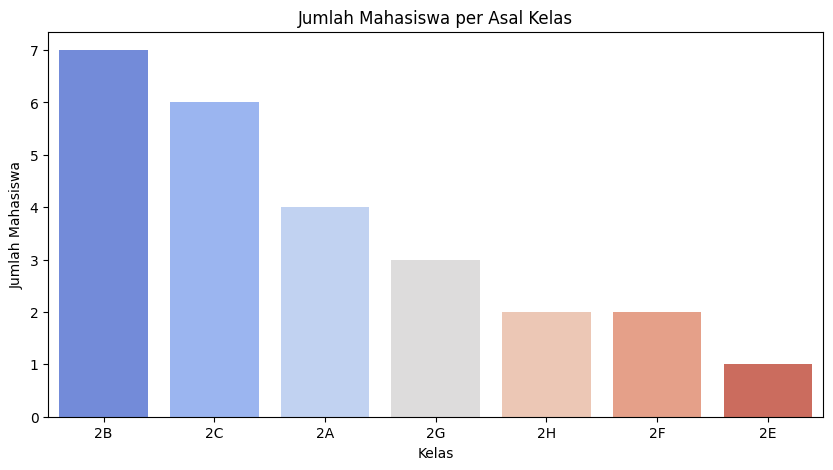

In [105]:
plt.figure(figsize=(10, 5))
sns.barplot(x=jumlah_kelas.index, y=jumlah_kelas.values, palette='coolwarm')
plt.title('Jumlah Mahasiswa per Asal Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

In [107]:
kelas_saya = df.loc[saya.index[0], 'kelas_bersih']
jumlah     = jumlah_kelas[kelas_saya]
peringkat  = list(jumlah_kelas.index).index(kelas_saya) + 1
total      = len(jumlah_kelas)

print(f"Kelas saya     : {kelas_saya}")
print(f"Jumlah anggota : {jumlah} orang")
print(f"Peringkat      : {peringkat} dari {total} kelas")

Kelas saya     : 2G
Jumlah anggota : 3 orang
Peringkat      : 4 dari 7 kelas


In [111]:
if jumlah == jumlah_kelas.max():
    print("banyak")
elif jumlah == jumlah_kelas.min():
    print("sedkit")
else:
    print("menengah")

menengah
